# Generative AI

## GAN and Diffusion

## Image Generation with OpenAI's DALL-E 2 vs. DALL-E 3 API

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = '<your API key here>'

from openai import OpenAI
import base64

client = OpenAI()

import matplotlib.pyplot as plt
from PIL import Image
import io
import requests

# ----------------- Config -----------------
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_DIR1 = "./outputs1"
os.makedirs(OUTPUT_DIR1, exist_ok=True)
#client = OpenAI()

# ----------------- Full Prompt Bank (50) -----------------
prompts = [
    "Photo of Victoria Memorial Hall in the winter. A yellow taxi is standing in front with snows over it. On the right, a boy is taking selfie.",
    "How the pyramids of Giza would look if they were built on the surface of the moon.",
    "The streets of Venice completely dried up, with people skateboarding where gondolas once floated.",
    "Snowfall in the Sahara desert, with camels walking through white dunes.",
    "How Times Square would look during the Roman Empire, with chariots and gladiators under neon lights.",
    "The Great Wall of China glowing with neon lights at night, as if it were a futuristic city.",
    "The Taj Mahal floating in the sky among the clouds.",
    "Rio de Janeiro during a massive snowstorm.",
    "The Eiffel Tower submerged underwater with scuba divers swimming around.",
    "New York’s Central Park transformed into a giant desert with sand dunes.",
    "A tropical jungle growing inside the Colosseum in Rome.",
    "Albert Einstein as a modern-day teenage skateboarder.",
    "A female version of Leonardo da Vinci painting the Mona Lisa.",
    "Tom Cruise reimagined as a child chess prodigy.",
    "Cleopatra reimagined as a 21st-century fashion model.",
    "Shakespeare as a sci-fi film director.",
    "A school of dolphins swimming through the sky among clouds.",
    "A giraffe riding a bicycle on a busy Tokyo street.",
    "A cat leading an orchestra in a grand concert hall.",
    "How a goldfish would look if it evolved to fly like a hummingbird.",
    "An elephant surfing giant waves in Hawaii.",
    "A lion wearing a business suit giving a TED talk.",
    "A penguin hiking Mount Everest.",
    "Owls driving cars on a highway at night.",
    "A horse competing in Formula 1 racing.",
    "Kangaroos shopping in a supermarket.",
    "New York City in the year 3025, with flying cars tangled in traffic jams in the sky."]

# ----------------- Helper to download image -----------------
def get_image(url):
    response = requests.get(url)
    return Image.open(io.BytesIO(response.content))

# ----------------- DALL-E 2 generator -----------------
def generate_dalle2(prompt):
    resp_base = client.images.generate(
        model="dall-e-2",
        prompt=prompt,
        size="1024x1024",
        n=1
    )
    base_img = get_image(resp_base.data[0].url)

    resp_vars = client.images.generate(
        model="dall-e-2",
        prompt=prompt,
        size="1024x1024",
        n=2
    )
    var1 = get_image(resp_vars.data[0].url)
    var2 = get_image(resp_vars.data[1].url)

    return base_img, var1, var2

# ----------------- DALL-E 3 generator -----------------
def generate_dalle3(prompt):
    resp_base = client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size="1024x1024"
    )
    base_img = get_image(resp_base.data[0].url)

    resp_var1 = client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size="1024x1024"
    )
    var1 = get_image(resp_var1.data[0].url)

    resp_var2 = client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size="1024x1024"
    )
    var2 = get_image(resp_var2.data[0].url)

    return base_img, var1, var2

# ----------------- Run for all prompts -----------------
for idx, prompt in enumerate(prompts, start=1):
    print(f"[{idx}/{len(prompts)}] Generating for prompt: {prompt}")

    try:
        dalle2_imgs = generate_dalle2(prompt)
        dalle3_imgs = generate_dalle3(prompt)

        fig, axes = plt.subplots(1, 3, figsize=(9, 4))
        fig.suptitle(f"Prompt {idx}: {prompt}", fontsize=12, weight="bold", wrap=True)

        # DALL-E 2 row
        axes[0].imshow(dalle2_imgs[0]); axes[0].set_title("DALL·E 2 (Base)")
        axes[1].imshow(dalle2_imgs[1]); axes[1].set_title("DALL·E 2 (Var 1)")
        axes[2].imshow(dalle2_imgs[2]); axes[2].set_title("DALL·E 2 (Var 2)")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        out_path = os.path.join(OUTPUT_DIR1, f"prompt_{idx:02d}.png")
        plt.savefig(out_path, dpi=150)
        plt.close()
        print(f"✅ Saved: {out_path}")

        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        fig.suptitle(f"Prompt {idx}: {prompt}", fontsize=12, weight="bold", wrap=True)

        # DALL-E 2 row
        axes[0, 0].imshow(dalle2_imgs[0]); axes[0, 0].set_title("DALL·E 2 (Base)")
        axes[0, 1].imshow(dalle2_imgs[1]); axes[0, 1].set_title("DALL·E 2 (Var 1)")
        axes[0, 2].imshow(dalle2_imgs[2]); axes[0, 2].set_title("DALL·E 2 (Var 2)")

        # DALL-E 3 row
        axes[1, 0].imshow(dalle3_imgs[0]); axes[1, 0].set_title("DALL·E 3 (Base)")
        axes[1, 1].imshow(dalle3_imgs[1]); axes[1, 1].set_title("DALL·E 3 (Var 1)")
        axes[1, 2].imshow(dalle3_imgs[2]); axes[1, 2].set_title("DALL·E 3 (Var 2)")

        for ax in axes.flatten():
            ax.axis("off")

        plt.tight_layout()
        out_path = os.path.join(OUTPUT_DIR, f"prompt_{idx:02d}.png")
        plt.savefig(out_path, dpi=150)
        plt.close()
        print(f"✅ Saved: {out_path}")

    except Exception as e:
        print(f"❌ Failed on prompt {idx}: {e}")

![](images/dall-e/prompt_01.png)
![](images/dall-e/dalle3.gif)

## OpenAI Image APIs — Generation, Editing, Inpainting, and Vision

### Analyze images

In [3]:
from openai import OpenAI
import base64

api_key = '<your API key here>'
client = OpenAI(api_key=api_key)

# 🔹 Encode image
def encode_image(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

image_path = "images/family.png"
base64_image = encode_image(image_path)

# 🔹 Convert to data URL (THIS IS THE FIX)
data_url = f"data:image/jpeg;base64,{base64_image}"

# 🔹 Send request
response = client.responses.create(
    model="gpt-4.1-mini",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "what's in this image?"},
            {
                "type": "input_image",
                "image_url": data_url,   # ✅ correct field
            },
        ],
    }],
)

print(response.output_text)

The image shows a group of five people sitting indoors. Among them, there are three elderly women and one elderly man, all dressed in traditional Indian attire, including sarees for the women and a checked shirt for the man. There is also a younger man standing at the right side of the group wearing a light blue polo shirt. The scene appears to be a family or social gathering. The room has a window in the background, and the lighting suggests the picture was taken indoors during the evening or night.


### Editing Images

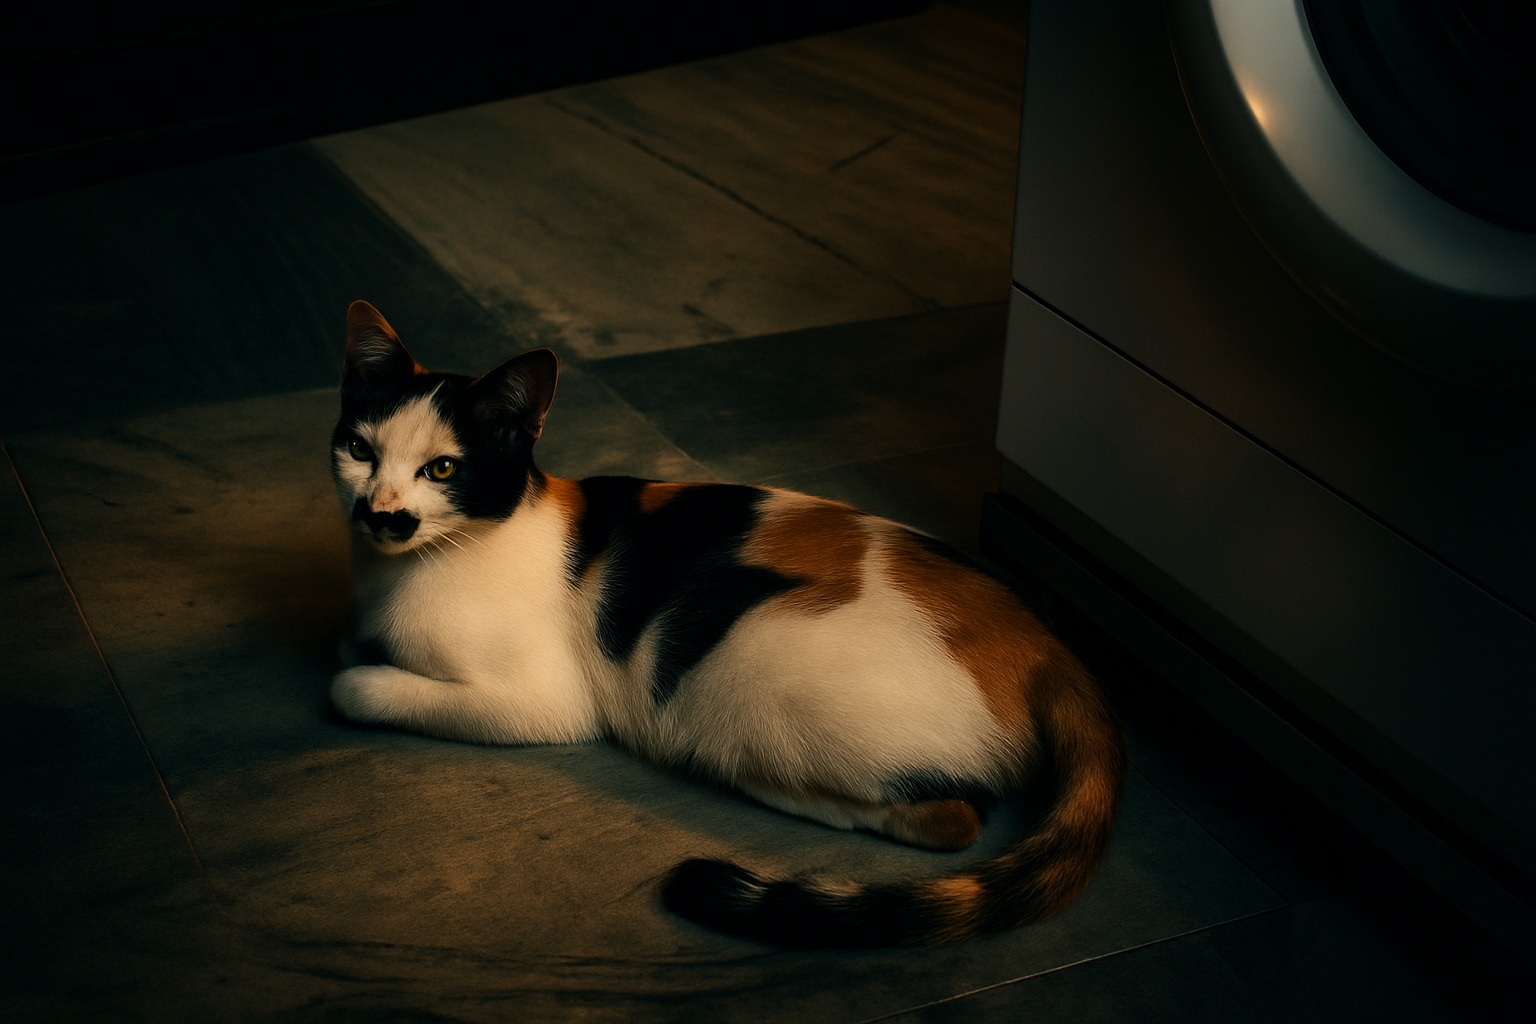

In [6]:
from PIL import Image

result = client.images.edit(
    model="gpt-image-1",
    image=open("images/cat.jpg", "rb"),
    prompt="Enhance lighting and make it cinematic",
)

image_base64 = result.data[0].b64_json

with open("images/cat_edited.png", "wb") as f:
    f.write(base64.b64decode(image_base64))

Image.open("images/cat_edited.png")

### Edge-based Editing

In [ ]:
import gradio as gr
import cv2
import numpy as np

def create_edge_mask(image_path):
    import cv2
    import numpy as np
    from PIL import Image

    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    edges = cv2.Canny(img, 100, 200)
    edges = cv2.resize(edges, (w, h))

    mask = np.zeros((h, w, 4), dtype=np.uint8)
    mask[..., 0] = edges
    mask[..., 1] = edges
    mask[..., 2] = edges
    mask[..., 3] = edges

    Image.fromarray(mask).save("images/mask.png")
    return mask

def edge_inpaint(image):
    mask = create_edge_mask(image)    
    #mask = (edges > 0).astype(np.uint8) * 255
    
    result = client.images.edit(
        model="gpt-image-1",
        image=open(image, "rb"),
        mask=open("images/mask.png", "rb"),
        prompt="Replace edges with artistic glowing lines"
    )

    img = base64.b64decode(result.data[0].b64_json)
    return Image.open(io.BytesIO(img))

gr.Interface(
    fn=edge_inpaint,
    inputs=gr.Image(type="filepath"),
    outputs=gr.Image(),
    title="OpenCV + GenAI Hybrid"
).launch()

![](images/gpt_edge_editing.png)

### Image Inpainting (Object Removal)

In [ ]:
import numpy as np

def fix_mask(mask_path):
    mask = Image.open(mask_path).convert("L")  # grayscale
    mask_np = np.array(mask)
    h, w = mask_np.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    # White → edit (transparent)
    rgba[..., 3] = 255 - mask_np   # alpha channel
    return Image.fromarray(rgba)

def inpaint(image, mask, prompt):
    if not prompt or prompt.strip() == "":
        prompt = "Fill the masked region naturally"

    # 🔥 Fix mask
    fixed_mask = fix_mask(mask)
    fixed_mask.save("fixed_mask.png")

    with open(image, "rb") as img_f, open("fixed_mask.png", "rb") as mask_f:
        result = client.images.edit(
            model="gpt-image-1",
            image=img_f,
            mask=mask_f,
            prompt=prompt
        )

    import base64, io
    from PIL import Image

    img = base64.b64decode(result.data[0].b64_json)
    return Image.open(io.BytesIO(img))

gr.Interface(
    fn=inpaint,
    inputs=[
        gr.Image(type="filepath", label="Image"),
        gr.Image(type="filepath", label="Mask (white = replace)"),
        gr.Textbox(
            label="Prompt",
            value="Fill the masked region realistically"
        )
    ],
    outputs=gr.Image(),
    title="AI Inpainting Tool"
).launch()

![](images/gpt_inpainting.png)

### AI Style Transfer

In [ ]:
import gradio as gr
from openai import OpenAI
import base64
from PIL import Image
import io

# 🔑 Initialize client
client = OpenAI(api_key=api_key)

# 🔧 Prompt builder with structure strength
def build_prompt(style, strength):
    if strength < 0.3:
        return f"""
        Transform this image into {style} style.
        Feel free to creatively reinterpret the scene.
        """

    elif strength < 0.7:
        return f"""
        Apply {style} style to this image.

        Preserve general composition and main objects,
        but allow moderate artistic reinterpretation.

        Modify colors, lighting, and textures.
        """

    else:
        return f"""
        Apply {style} style to this image.

        STRICT INSTRUCTIONS:
        - Preserve composition, layout, and geometry EXACTLY
        - Do NOT change object shapes, positions, or proportions
        - Do NOT add or remove objects
        - Maintain identical perspective

        ONLY modify:
        - colors
        - textures
        - lighting

        This must look like the SAME image, only stylized.
        """


# 🔧 Main function
def style_transfer(image_path, style_choice, custom_style, strength):
    style = custom_style if custom_style.strip() else style_choice

    prompt = build_prompt(style, strength)

    result = client.images.edit(
        model="gpt-image-1",
        image=open(image_path, "rb"),
        prompt=prompt,
        size="1024x1024"
    )

    img_bytes = base64.b64decode(result.data[0].b64_json)
    return Image.open(io.BytesIO(img_bytes))


# 🎨 Style presets
styles = [
    "Studio Ghibli style (soft pastel colors, hand-painted anime, warm lighting, whimsical atmosphere)",
    "Van Gogh painting",
    "watercolor painting",
    "cyberpunk neon",
    "anime style",
    "pencil sketch",
    "oil painting",
    "photorealistic cinematic"
]


# 🖥️ Gradio UI
with gr.Blocks() as demo:
    gr.Markdown("# 🎨 AI Style Transfer with Structure Control")
    gr.Markdown("Control how much the original image is preserved")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="filepath", label="Upload Image")

            style_dropdown = gr.Dropdown(styles, label="Choose Style")
            custom_style = gr.Textbox(label="Or Enter Custom Style")

            structure_slider = gr.Slider(
                minimum=0.0,
                maximum=1.0,
                value=0.8,
                step=0.1,
                label="Structure Preservation (Weak → Strong)"
            )

            run_btn = gr.Button("Apply Style")

        with gr.Column():
            output_image = gr.Image(label="Stylized Output")

    run_btn.click(
        fn=style_transfer,
        inputs=[input_image, style_dropdown, custom_style, structure_slider],
        outputs=output_image
    )

demo.launch()

![](images/gpt_us_ghibly.png)
![](images/gpt_family_ghibly.png)
![](images/gpt_family_sketch.jpg)

### Multi-Image Composition

In [14]:
import gradio as gr
from openai import OpenAI
import base64
from PIL import Image
import io

client = OpenAI(api_key=api_key)

result = client.images.edit(
    model="gpt-image-1",
    image=[
        open("images/beach.png", "rb"),
        open("images/whale.jpg", "rb"),
    ],
    prompt="Combine these into a realistic product scene"
)

image_base64 = result.data[0].b64_json
with open("images/gpt_composition2.png", "wb") as f:
    f.write(base64.b64decode(image_base64))

![](images/gpt_composition.png)
![](images/gpt_composition2.png)

### E-commerce Product Enhancer

In [ ]:
def ecommerce(image_path):
    # 🔥 FIX: open file properly
    with open(image_path, "rb") as f:
        result = client.images.edit(
            model="gpt-image-1",
            image=f,   # ✅ now valid
            prompt="Place this product in a professional studio background with soft lighting"
        )

    img = base64.b64decode(result.data[0].b64_json)
    return Image.open(io.BytesIO(img))


gr.Interface(
    fn=ecommerce,
    inputs=gr.Image(type="filepath"),
    outputs=gr.Image(),
    title="E-commerce Product Generator"
).launch()

![](images/ecom.png)

### Vision QA

In [ ]:
def analyze(image, question):
    with open(image, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()

    data_url = f"data:image/jpeg;base64,{b64}"

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=[{
            "role": "user",
            "content": [
                {"type": "input_text", "text": question},
                {"type": "input_image", "image_url": data_url}
            ]
        }]
    )

    return response.output_text

gr.Interface(
    fn=analyze,
    inputs=[
        gr.Image(type="filepath"),
        gr.Textbox(label="Ask about image")
    ],
    outputs=gr.Textbox(),
    title="Visual QA System"
).launch()

![](images/gpt_vqa.png)